## MOSAiC track LWP extraction from Climate-DT story-nudging

This notebook reads an hourly ship track (time, latitude, longitude), requests total column liquid water (LWP, `tclw`) from the Climate-DT story-nudging experiment via Polytope/Earthkit, and writes the merged results to CSV.

The extraction is done day-by-day so each ship position on a given day is sampled from that day's model field.

### Authentication
Run the authentication helper from the repository root if needed.

In [1]:
%%capture cap
%run ../../desp-authentication.py

In [2]:
output_1 = cap.stdout.split('}\n')
access_token = output_1[-1][0:-1]
print('Authentication token captured.')

Authentication token captured.


### Imports

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import earthkit.data
import matplotlib.pyplot as plt

### Settings

In [ ]:
TRACK_FILE = Path('MOSAiC_track_1h.txt')


### Read and prepare ship track

In [3]:
track = pd.read_csv(TRACK_FILE, delim_whitespace=True)
track = track.rename(columns={'Datetime': 'time_raw', 'Latitude': 'lat', 'Longitude': 'lon'})
track['time'] = pd.to_datetime(track['time_raw'].astype(str), format='%Y%m%d%H', utc=True).dt.tz_convert(None)
track = track[['time', 'lat', 'lon']].copy()

# Normalize longitude to [-180, 180] for consistency in output.
track['lon'] = ((track['lon'] + 180.0) % 360.0) - 180.0
track['date_str'] = track['time'].dt.strftime('%Y%m%d')
track['time_str'] = track['time'].dt.strftime('%H%M')

track.head()

/etc/ecmwf/ssd/ssd1/ecinteractive/nelc-ecinteractive/tmpdirs/nelc.44654641/ipykernel_2755944/2310415831.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  track = pd.read_csv(TRACK_FILE, delim_whitespace=True)


,time,lat,lon,date_str,time_str
0,2019-09-20 17:00:00,69.67955,18.99664,20190920,1700
1,2019-09-20 18:00:00,69.67955,18.99665,20190920,1800
2,2019-09-20 19:00:00,69.68378,19.02527,20190920,1900
3,2019-09-20 20:00:00,69.80262,19.41134,20190920,2000
4,2019-09-20 21:00:00,69.91434,19.89519,20190920,2100


In [4]:
print(f'Track rows: {len(track):,}')
print(f'Date range: {track.time.min()} to {track.time.max()}')
print(f'Unique days: {track.date_str.nunique():,}')

Track rows: 9,301
Date range: 2019-09-20 17:00:00 to 2020-10-12 05:00:00
Unique days: 389


In [ ]:
import logging, warnings
import earthkit.data

# Set temporary cache directory root to a location with sufficient space
s = {"cache-policy": "temporary", "temporary-cache-directory-root": "/ec/res4/scratch/nelc/climate-dt/data/ekdata"}
earthkit.data.config.set(s)
earthkit.data.cache.directory()

print(earthkit.data.config.get("cache-policy"))

earthkit.data.config.set({"maximum-cache-size": None})
print(earthkit.data.config.get("maximum-cache-size"))

# # Silence verbose output from polytope / earthkit internals
# for _ln in ("polytope", "polytope.api", "earthkit.data", "urllib3"):
#     logging.getLogger(_ln).setLevel(logging.WARNING)
# warnings.filterwarnings("ignore", category=DeprecationWarning)

temporary


In [7]:
# # check if packages are in the venv, if not, install them
# import subprocess
# import sys
# def install(package):
#     subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# requirements_path = "/home/nelc/Projects/ClimateDT/polytope-examples/climate-dt/requirements.txt"
# with open(requirements_path) as f:
#     for line in f:
#         package = line.strip()
#         if package:
#             install(package)

In [8]:
import healpy as hp
import matplotlib.pyplot as plt


In [9]:
import sys
sys.path.append('../explorer')
from polytope_zarr import PolytopeZarrStore


In [10]:
story_store = PolytopeZarrStore.from_climate_dt(
    models=["IFS-FESOM"],
    experiment=["cont", "hist", "Tplus2.0K"],
    activity="story-nudging",
    levtype="sfc",
    frequency="hourly",
    start_date="2017-01-01T00:00:00",
    end_date="2024-12-31T23:00:00",
    resolution="standard",
)
print(story_store)

<PolytopeZarrStore 34 variables (time=70128, cell=196608, climate=3)>


In [11]:
story_store

<PolytopeZarrStore 34 variables (time=70128, cell=196608, climate=3)>

In [12]:
ds_story = story_store.open()
ds_story

<xarray.Dataset> Size: 6TB
Dimensions:       (climate: 3, time: 70128, cell: 196608)
Coordinates:
  * climate       (climate) object 24B 'cont' 'hist' 'Tplus2.0K'
  * time          (time) datetime64[ns] 561kB 2017-01-01 ... 2024-12-31T23:00:00
  * cell          (cell) int32 786kB 0 1 2 3 4 ... 196604 196605 196606 196607
Data variables: (12/34)
    10si          (climate, time, cell) float32 165GB ...
    10u           (climate, time, cell) float32 165GB ...
    10v           (climate, time, cell) float32 165GB ...
    2d            (climate, time, cell) float32 165GB ...
    2t            (climate, time, cell) float32 165GB ...
    avg_ie        (climate, time, cell) float32 165GB ...
    ...            ...
    sp            (climate, time, cell) float32 165GB ...
    tcc           (climate, time, cell) float32 165GB ...
    tciw          (climate, time, cell) float32 165GB ...
    tclw          (climate, time, cell) float32 165GB ...
    tcw           (climate, time, cell) float32 165GB ...
    tcwv          (climate, time, cell) float32 165GB ...
Attributes:
    _polytope_store:  <PolytopeZarrStore 34 variables (time=70128, cell=19660...

Fetching {'cell': 196608} values...
Fetching {'cell': 196608} values...
Fetching {'cell': 196608} values...
  ⚡ batching 24 time chunks for 2t


2026-08-06 09:44:22 - INFO - Key read from /home/nelc/.polytopeapirc
2026-08-06 09:44:22 - INFO - Sending request...
{'request': 'activity: story-nudging\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            "date: '20190725'\n"
            'experiment: hist\n'
            "expver: '0001'\n"
            "generation: '2'\n"
            'levtype: sfc\n'
            'model: IFS-FESOM\n'
            'param: 2t\n'
            "realization: '1'\n"
            'resolution: standard\n'
            'stream: clte\n'
            'time: '
            '0000/0100/0200/0300/0400/0500/0600/0700/0800/0900/1000/1100/1200/1300/1400/1500/1600/1700/1800/1900/2000/2100/2200/2300\n'
            'type: fc\n',
 'verb': 'retrieve'}
2026-08-06 09:44:22 - INFO - Polytope user key found in session cache for user nelc
2026-08-06 09:44:22 - INFO - Request accepted. Please poll ./01f3z8k982zz8zc005jqbnabj2 for status
2026-08-06 09:44:22 - INFO - Polytope user key found in session cache for user

01f3z8k982zz8zc005jqbnabj2:   0%|          | 0.00/10.5M [00:00<?, ?B/s]

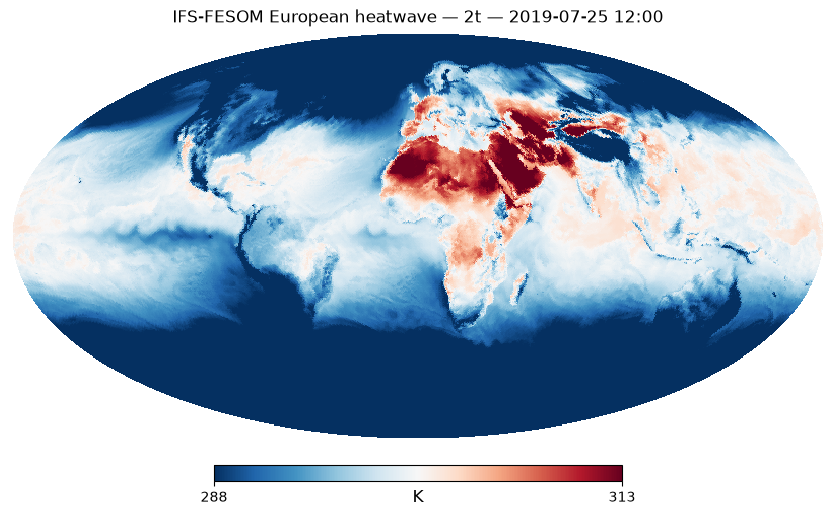

In [13]:
# Try example
# Note: look at Paris heatwave on 2019-07-25
field_story_PI = ds_story["2t"].sel(climate="cont", time="2019-07-25T12:00")
print(f"Fetching {dict(field_story_PI.sizes)} values...")

field_story_PD = ds_story["2t"].sel(climate="hist", time="2019-07-25T12:00")
print(f"Fetching {dict(field_story_PD.sizes)} values...")

field_story_2K = ds_story["2t"].sel(climate="Tplus2.0K", time="2019-07-25T12:00")
print(f"Fetching {dict(field_story_2K.sizes)} values...")

hp.mollview(field_story_PD.values, title="IFS-FESOM European heatwave — 2t — 2019-07-25 12:00",
            unit="K", cmap="RdBu_r", nest=True, flip="geo", min=288, max=313)
plt.show()

Fetching {'cell': 196608} values...
Fetching {'cell': 196608} values...
Fetching {'cell': 196608} values...
Fetching {'cell': 196608} values...
Fetching {'cell': 196608} values...
Fetching {'cell': 196608} values...
  ⚡ batching 24 time chunks for tcwv


01f3z8k982zz8zm005cfkfg6k9:   0%|          | 0.00/11.0M [00:00<?, ?B/s]

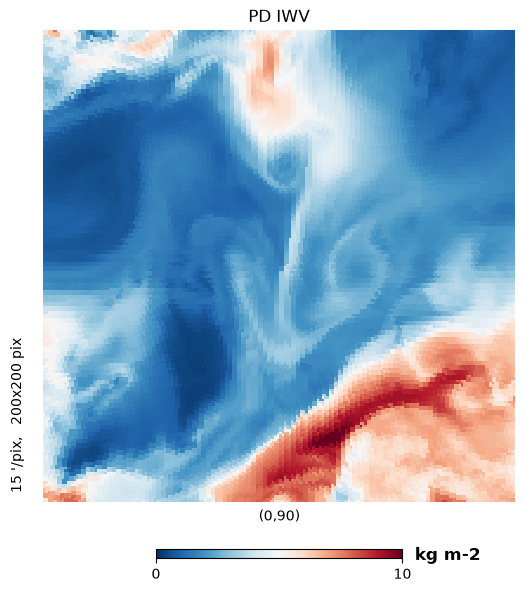

  ⚡ batching 24 time chunks for tcwv


01f3z8k982zz8zt005m7t4a7y2:   0%|          | 0.00/11.1M [00:00<?, ?B/s]

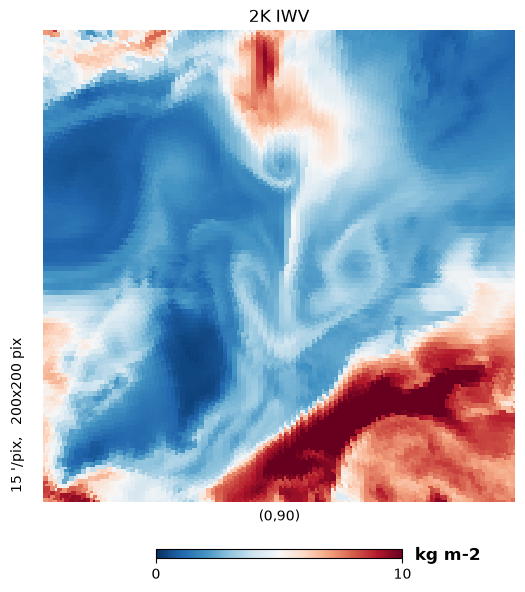

  ⚡ batching 24 time chunks for tclw


01f3z8k982zz8zy005sgfhwm8x:   0%|          | 0.00/10.1M [00:00<?, ?B/s]

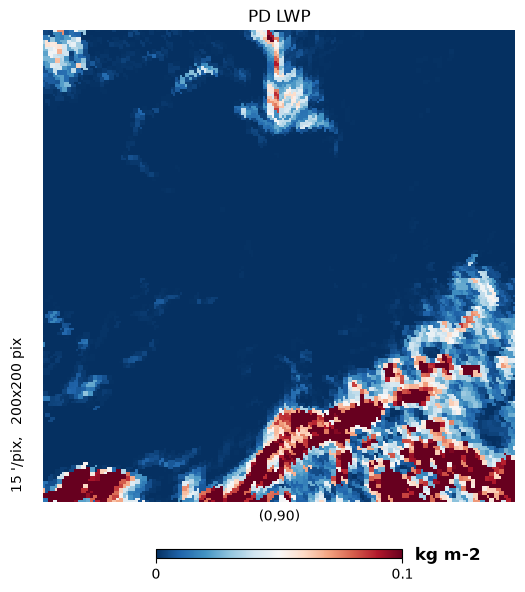

  ⚡ batching 24 time chunks for tclw


01f3z8k982zz9040050g6b9hpq:   0%|          | 0.00/10.2M [00:00<?, ?B/s]

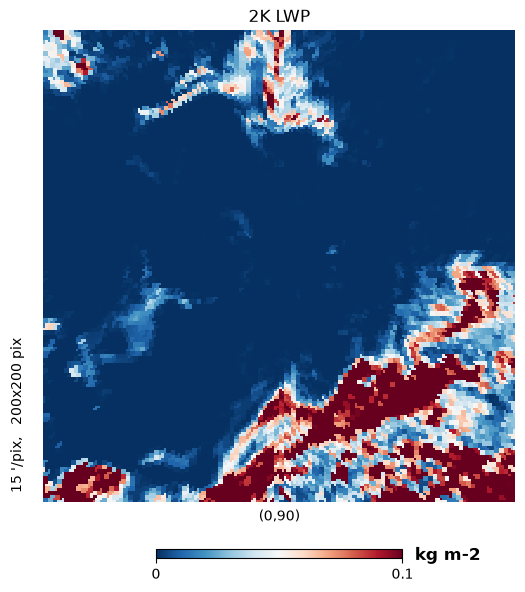

In [ ]:
# Note: Look at Arctic Warm air intrusion on 2019-12-17
field_story_PI_IWV = ds_story["tcwv"].sel(climate="cont", time="2019-12-17T12:00")
print(f"Fetching {dict(field_story_PI_IWV.sizes)} values...")

field_story_PD_IWV = ds_story["tcwv"].sel(climate="hist", time="2019-12-17T15:00")
print(f"Fetching {dict(field_story_PD_IWV.sizes)} values...")

field_story_2K_IWV = ds_story["tcwv"].sel(climate="Tplus2.0K", time="2019-12-17T12:00")
print(f"Fetching {dict(field_story_2K_IWV.sizes)} values...")



hp.mollview(field_story_PD_IWV.values, title="IFS-FESOM Warm air intrusion — tcwv — 2019-12-17 12:00",
            unit="kg m-2", cmap="RdBu_r", nest=True, flip="geo", min=0, max=10)

plt.show()

In [16]:
# Fetch some data to get lat/lon coordinates for the track
r = story_store.last_request

data = earthkit.data.from_source("polytope", r["collection"], r["request"],
                                 address=r["address"], stream=False)

field = data.to_xarray(add_geo_coords=True)
field


<xarray.Dataset> Size: 41MB
Dimensions:                  (forecast_reference_time: 24, values: 196608)
Coordinates:
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 192B 20...
    latitude                 (values) float64 2MB ...
    longitude                (values) float64 2MB ...
Dimensions without coordinates: values
Data variables:
    tclw                     (forecast_reference_time, values) float64 38MB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

In [17]:
track

,time,lat,lon,date_str,time_str
0,2019-09-20 17:00:00,69.67955,18.99664,20190920,1700
1,2019-09-20 18:00:00,69.67955,18.99665,20190920,1800
2,2019-09-20 19:00:00,69.68378,19.02527,20190920,1900
3,2019-09-20 20:00:00,69.80262,19.41134,20190920,2000
4,2019-09-20 21:00:00,69.91434,19.89519,20190920,2100
...,...,...,...,...,...
9296,2020-10-12 01:00:00,54.15229,7.45162,20201012,0100
9297,2020-10-12 02:00:00,54.03084,7.56408,20201012,0200
9298,2020-10-12 03:00:00,53.90926,7.68643,20201012,0300
9299,2020-10-12 04:00:00,53.83636,8.06298,20201012,0400


In [18]:
# find index of nearest neighbor to a given lat/lon point in the dataset
ref_point_idx, distance = earthkit.geo.distance.nearest_point_haversine((track.lat.values, track.lon.values), (field.latitude, field.longitude))
ref_point_idx

array([15152, 15152, 15152, ..., 11839, 11839, 11837], shape=(9301,))

In [20]:
# Add time dimension to the moving cell index list for use in xarray selection
import xarray as xr
times = track['time'].values
moving_cell = xr.DataArray(
    # idx_list, dims=["time"], coords={"time": times}
    ref_point_idx, dims=["time"], coords={"time": times}
)

In [21]:
ds_story

<xarray.Dataset> Size: 6TB
Dimensions:       (climate: 3, time: 70128, cell: 196608)
Coordinates:
  * climate       (climate) object 24B 'cont' 'hist' 'Tplus2.0K'
  * time          (time) datetime64[ns] 561kB 2017-01-01 ... 2024-12-31T23:00:00
  * cell          (cell) int32 786kB 0 1 2 3 4 ... 196604 196605 196606 196607
Data variables: (12/34)
    10si          (climate, time, cell) float32 165GB ...
    10u           (climate, time, cell) float32 165GB ...
    10v           (climate, time, cell) float32 165GB ...
    2d            (climate, time, cell) float32 165GB ...
    2t            (climate, time, cell) float32 165GB ...
    avg_ie        (climate, time, cell) float32 165GB ...
    ...            ...
    sp            (climate, time, cell) float32 165GB ...
    tcc           (climate, time, cell) float32 165GB ...
    tciw          (climate, time, cell) float32 165GB ...
    tclw          (climate, time, cell) float32 165GB ...
    tcw           (climate, time, cell) float32 165GB ...
    tcwv          (climate, time, cell) float32 165GB ...
Attributes:
    _polytope_store:  <PolytopeZarrStore 34 variables (time=70128, cell=19660...

In [ ]:
# Select the moving cell along the track for all times in the track
mosaic_timeseries = ds_story.sel(time=times).sel(cell=moving_cell, method='nearest')
mosaic_timeseries

<xarray.Dataset> Size: 4MB
Dimensions:       (climate: 3, time: 9301)
Coordinates:
  * climate       (climate) object 24B 'cont' 'hist' 'Tplus2.0K'
  * time          (time) datetime64[ns] 74kB 2019-09-20T17:00:00 ... 2020-10-...
    cell          (time) int32 37kB 15152 15152 15152 ... 11839 11839 11837
Data variables: (12/34)
    10si          (climate, time) float32 112kB ...
    10u           (climate, time) float32 112kB ...
    10v           (climate, time) float32 112kB ...
    2d            (climate, time) float32 112kB ...
    2t            (climate, time) float32 112kB ...
    avg_ie        (climate, time) float32 112kB ...
    ...            ...
    sp            (climate, time) float32 112kB ...
    tcc           (climate, time) float32 112kB ...
    tciw          (climate, time) float32 112kB ...
    tclw          (climate, time) float32 112kB ...
    tcw           (climate, time) float32 112kB ...
    tcwv          (climate, time) float32 112kB ...
Attributes:
    _polytope_store:  <PolytopeZarrStore 34 variables (time=70128, cell=19660...

In [24]:
mosaic_obs = xr.open_dataset('/perm/nelc/mosaic/merged/mosaic_obs_combined_hourly.nc')
mosaic_obs

<xarray.Dataset> Size: 3MB
Dimensions:                    (time: 9076)
Coordinates:
  * time                       (time) datetime64[ns] 73kB 2019-09-20 ... 2020...
Data variables: (12/49)
    temp_2m                    (time) float64 73kB ...
    temp_6m                    (time) float64 73kB ...
    temp_10m                   (time) float64 73kB ...
    skin_temp_surface          (time) float64 73kB ...
    rh_2m                      (time) float64 73kB ...
    rh_6m                      (time) float64 73kB ...
    ...                         ...
    up_short_hemisp_asfs50     (time) float64 73kB ...
    visibility                 (time) float64 73kB ...
    down_long_hemisp_mean      (time) float64 73kB ...
    up_long_hemisp_mean        (time) float64 73kB ...
    down_short_hemisp_mean     (time) float64 73kB ...
    up_short_hemisp_mean       (time) float64 73kB ...
Attributes: (12/22)
    date_created:              Fri Feb  3 13:30:54 2023
    title:                     MOSAiC flux group data product
    contact:                   Matthew Shupe, University of Colorado, matthew...
    institution:               CIRES, University of Colorado and NOAA Physica...
    file_creator:              Michael R. Gallagher; Christopher J. Cox
    creator_email:             michael.r.gallagher@noaa.gov; christopher.j.co...
    ...                        ...
    instrument_heights:        Instruments were installed at nominal heights....
    quality_control:           Significant quality control is in place for th...
    qc_flags:                  -1 = No Data: Instrument was not functional an...
    wind_sector_qc_info_flag:  Quality control flags specifically for wind se...
    turbulence_qc_flags:       Applies to all derived EC-based turbulence par...
    bulk_qc_flags:             Applies to all derived bulk-based turbulence p...

  ⚡ batching 24 time chunks for tcwv


01f3z8k982zz96g005m6fykzma:   0%|          | 0.00/11.3M [00:00<?, ?B/s]

  ⚡ batching 24 time chunks for tcwv


01f3z8k982zz96m005tje2zmkb:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

  ⚡ batching 24 time chunks for tcwv


...

01f3z8k982zz9n00054jcz93a3:   0%|          | 0.00/11.5M [00:00<?, ?B/s]

  ⚡ batching 24 time chunks for avg_sdlwrf


01f3z8k982zz9n6005fjfp2k6n:   0%|          | 0.00/11.5M [00:00<?, ?B/s]

  ⚡ batching 24 time chunks for avg_sdlwrf


01f3z8k982zz9ne0051v97mx7m:   0%|          | 0.00/11.5M [00:00<?, ?B/s]

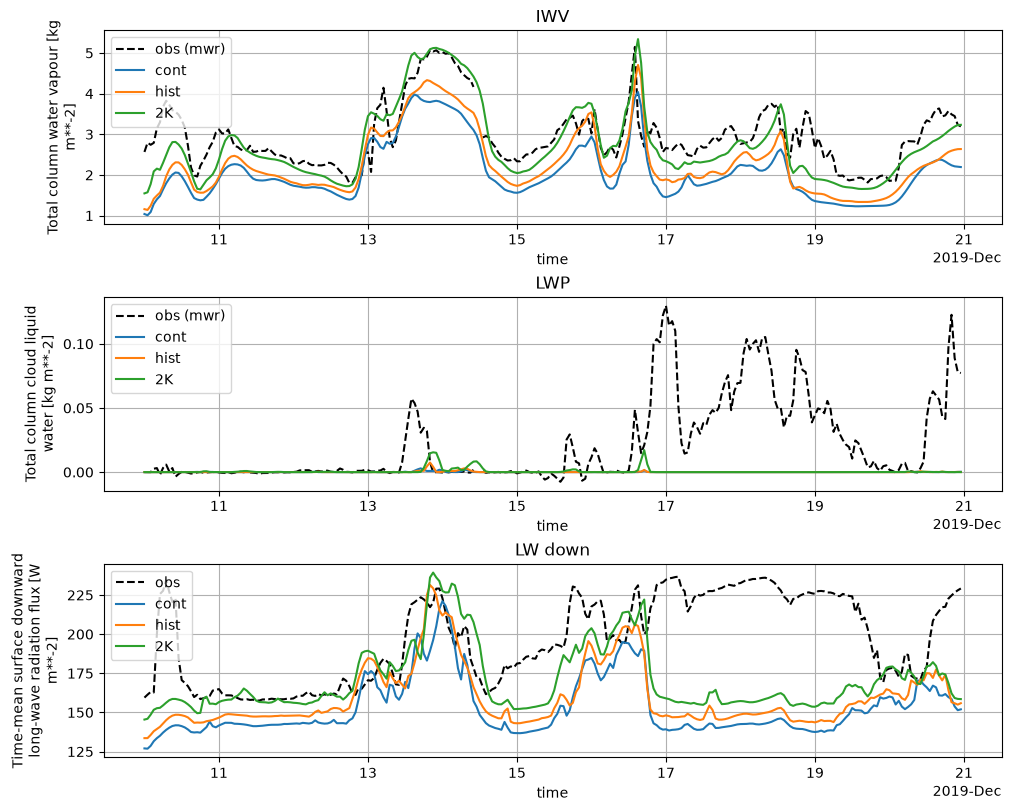

In [25]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10, 8), layout='constrained')

# time_slice = slice("2019-12-01", "2019-12-04")
# time_slice = slice("2019-12-15", "2019-12-20")
time_slice = slice("2019-12-10", "2019-12-20")
obs_slice = mosaic_obs.sel(time=time_slice)

plt.sca(axs[0])
obs_slice['iwv_hatpro_miracp'].plot(label='obs (mwr)', color='black', linestyle='--')
var = 'tcwv'
mosaic_timeseries[var].sel(climate='cont').sel(time=time_slice).plot(label='cont')
mosaic_timeseries[var].sel(climate='hist').sel(time=time_slice).plot(label='hist')
mosaic_timeseries[var].sel(climate='Tplus2.0K').sel(time=time_slice).plot(label='2K')
plt.title("IWV")
plt.legend()

plt.sca(axs[1])
obs_slice['lwp_hatpro'].plot(label='obs (mwr)', color='black', linestyle='--')
var = 'tclw'
mosaic_timeseries[var].sel(climate='cont').sel(time=time_slice).plot(label='cont')
mosaic_timeseries[var].sel(climate='hist').sel(time=time_slice).plot(label='hist')
mosaic_timeseries[var].sel(climate='Tplus2.0K').sel(time=time_slice).plot(label='2K')
plt.title("LWP")
plt.legend()

plt.sca(axs[2])
obs_slice['down_long_hemisp_mean'].plot(label='obs', color='black', linestyle='--')
var = 'avg_sdlwrf'
mosaic_timeseries[var].sel(climate='cont').sel(time=time_slice).plot(label='cont')
mosaic_timeseries[var].sel(climate='hist').sel(time=time_slice).plot(label='hist')
mosaic_timeseries[var].sel(climate='Tplus2.0K').sel(time=time_slice).plot(label='2K')
plt.title("LW down")
plt.legend(loc='upper left')

for ax in axs:
    ax.grid()